In [1]:
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras import layers, models, regularizers
from keras.optimizers import Adam
from keras.optimizers.schedules import CosineDecay
from keras.callbacks import ModelCheckpoint
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import load_model
from keras import Model
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

2026-09-03 22:55:18.172521: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-03 22:55:18.193861: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-03 22:55:18.200342: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-03 22:55:18.216339: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-03 22:55:19.185967: W tensorflow/compiler/tf2

In [15]:
def load_physics_dataset(files, features, labels=None, N_particles_max=50):
    events = []
    event_labels = []

    if labels is not None:
        if len(labels) == 1:
            labels = labels * len(files)
        else:
            assert len(labels) == len(files)

    for i, fname in enumerate(files):
        df = pd.read_parquet(fname)
        label = labels[i] if labels is not None else None

        for idx in range(len(df)):
            event_features = []

            for feat in features:
                arr = np.asarray(df[feat].iloc[idx], dtype=np.float32)

                if len(arr) > N_particles_max:
                    arr = arr[:N_particles_max]
                else:
                    padded = np.zeros(N_particles_max, dtype=np.float32)
                    padded[:len(arr)] = arr
                    arr = padded

                event_features.append(arr)

            event_tensor = np.stack(event_features, axis=1)
            events.append(event_tensor)

            if label is not None:
                event_labels.append(label)

    X = np.asarray(events, dtype=np.float32)
    y = np.asarray(event_labels, dtype=np.int64) if labels is not None else None

    return X, y



def preprocess_particles(X, feature_indices=[0,1,2,3], pt_index=0, eta_index=1, phi_index=2,
                         d0_index=3, eta_range=(-5.0, 5.0)):

    X_proc = X.copy()

    pt = X_proc[:, :, pt_index]
    pt_logged = np.log(pt + 1.0)
    pt_min, pt_max = pt_logged.min(), pt_logged.max()
    X_proc[:, :, pt_index] = (pt_logged - pt_min) / (pt_max - pt_min + 1e-8)

    eta = X_proc[:, :, eta_index]
    eta_min, eta_max = eta_range
    X_proc[:, :, eta_index] = (eta - eta_min) / (eta_max - eta_min)
    X_proc[:, :, eta_index] = np.clip(X_proc[:, :, eta_index], 0.0, 1.0)

    d0 = X_proc[:, :, d0_index]
    d0_min, d0_max = d0.min(), d0.max()
    X_proc[:, :, d0_index] = (d0 - d0_min) / (d0_max - d0_min + 1e-8)

    phi = X_proc[:, :, phi_index]
    phi_cos = np.cos(phi)
    phi_sin = np.sin(phi)

    X_proc = np.delete(X_proc, phi_index, axis=2)
    X_proc = np.concatenate([X_proc, phi_cos[..., np.newaxis], phi_sin[..., np.newaxis]], axis=2)

    return X_proc


def load_test_data(df, features, labels=None, N_particles_max=50):

    events = []

    if labels is not None:
        assert len(labels) == len(df), "Labels must match number of events"

    for idx, row in df.iterrows():
        event_features = []
        for feat in features:
            arr = np.asarray(row[feat], dtype=np.float32)
            if len(arr) > N_particles_max:
                arr = arr[:N_particles_max]
            else:
                padded = np.zeros(N_particles_max, dtype=np.float32)
                padded[:len(arr)] = arr
                arr = padded
            event_features.append(arr)
        event_tensor = np.stack(event_features, axis=1)  # shape (N_particles, N_features)
        events.append(event_tensor)

    X = np.asarray(events, dtype=np.float32)
    y = np.asarray(labels, dtype=np.int64) if labels is not None else None
    return X, y

In [16]:
CERNBOX_TOKEN = "cK4cbOHaCwfYUKy"
CERNBOX_BASE  = f"https://cernbox.cern.ch/remote.php/dav/public-files/{CERNBOX_TOKEN}"

In [17]:
files = [
    CERNBOX_BASE+'/HH_4b.parquet',
    CERNBOX_BASE+'/DYJetsToLL_13TeV-madgraphMLM-pythia8.parquet',
    CERNBOX_BASE+'/QCD_HT50toInf.parquet',
    CERNBOX_BASE+'/WJetsToLNu_13TeV-madgraphMLM-pythia8.parquet'
]

features = [            #The features per particle in the event, Kinematics + displacement from PV
    'L1T_PFPart_PT',
    'L1T_PFPart_Eta',
    'L1T_PFPart_Phi',
    'L1T_PFPart_D0'
]


labels = [1,0,0,0]   # HH=1, DY=2, QCD=0, WJets=3

X, y = load_physics_dataset(
    files,
    features,
    labels=labels,
    N_particles_max=16
)

print(X.shape)  # (N total events, N particles per event, N features per particle)
print(y.shape)  # (N total events)

(230985, 16, 4)
(230985,)


In [5]:
X_proc = preprocess_particles(X) #Here, we are normalising the input data to put features on the same scale. Because Phi is periodic, we encode as sine and cosine so we expand the feature dimension
print(X_proc.shape)

(230985, 16, 5)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y, test_size=0.4, random_state=42, stratify=y, shuffle = True
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.2, random_state=42, stratify=y_test, shuffle = True
)

In [7]:
# MLP
input_shape = X_train.shape[1:]
n_classes = len(set(y_train))
inputs = layers.Input(shape=input_shape)

initial_lr = 1e-3
epochs = 20
steps_per_epoch = X_train.shape[0] // 512
lr_schedule = CosineDecay(
    initial_learning_rate=initial_lr,
    decay_steps=epochs * steps_per_epoch,
    alpha=1e-4
)

optimizer = Adam(learning_rate=lr_schedule)

x = layers.Flatten()(inputs)

x = layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
# Fundamental theorem of learning theory: High-D embedding space can make complex data linearly separable
x = layers.Dropout(0.1)(x)

x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x) #Weight decay
x = layers.Dropout(0.1)(x) #Skip connections

x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.1)(x)

x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.1)(x)

x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
# Disentangle features in high-D space, then compress to learn high-quality representations
x = layers.Dropout(0.1)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

mlp_model = models.Model(inputs, outputs)

mlp_model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

checkpoint_cb = ModelCheckpoint(
    filepath="mlp_best_model.keras",
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

history = mlp_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    shuffle=True,
    callbacks=[checkpoint_cb]
)


2026-09-03 22:55:52.363888: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20480 MB memory:  -> device: 0, name: NVIDIA A10, pci bus id: 0000:c1:00.0, compute capability: 8.6


Epoch 1/20


I0000 00:00:1788476155.221624   19712 service.cc:146] XLA service 0x717e00008010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788476155.221655   19712 service.cc:154]   StreamExecutor device (0): NVIDIA A10, Compute Capability 8.6
2026-09-03 22:55:55.285521: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-03 22:55:55.552187: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


 110/2166 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7287 - auc: 0.6230 - loss: 0.6769

I0000 00:00:1788476158.490182   19712 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2166/2166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8332 - auc: 0.8635 - loss: 0.4460

2026-09-03 22:56:06.717453: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77', 336 bytes spill stores, 336 bytes spill loads

2026-09-03 22:56:07.033173: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77', 132 bytes spill stores, 132 bytes spill loads

2026-09-03 22:56:12.207491: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77', 20 bytes spill stores, 20 bytes spill loads

2026-09-03 22:56:12.618321: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77', 368 bytes spill stores, 368 bytes spill loads

2026-09-03 22:56:12.868247: I external/local_xla/xla/stream_ex


Epoch 1: val_auc improved from None to 0.91074, saving model to mlp_best_model.keras
2166/2166 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8486 - auc: 0.8924 - loss: 0.3938 - val_accuracy: 0.8617 - val_auc: 0.9107 - val_loss: 0.3483
Epoch 2/20
2139/2166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8597 - auc: 0.9085 - loss: 0.3485
Epoch 2: val_auc improved from 0.91074 to 0.91859, saving model to mlp_best_model.keras
2166/2166 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8623 - auc: 0.9112 - loss: 0.3421 - val_accuracy: 0.8692 - val_auc: 0.9186 - val_loss: 0.3274
Epoch 3/20
2166/2166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8678 - auc: 0.9182 - loss: 0.3280
Epoch 3: val_auc improved from 0.91859 to 0.91906, saving model to mlp_best_model.keras
2166/2166 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8693 - auc: 0.9197 - loss: 0.3254 - val_accuracy: 0.8690 - val_auc: 0.9191 - val_loss: 0.3256
Epoch 4/20
2156/2166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8700 - auc: 

In [9]:
def evaluate_model(model, X, y, model_name="Model"):
    y_pred = np.argmax(model.predict(X, batch_size=512), axis=1)

    acc = np.mean(y_pred == y)
    print(f"\n=== {model_name} ===")
    print(f"Test Accuracy: {acc:.3f}\n")

    print("Classification Report:")
    print(classification_report(y, y_pred, digits=3))

    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(cm)

    return acc, y_pred, cm

In [10]:
mlp = load_model("mlp_best_model.h5")
#transformer = load_model("transformer_best_model.keras", custom_objects={'CLSToken': CLSToken, 'ExtractCLS': ExtractCLS})

In [11]:
mlp_acc, mlp_pred, mlp_cm = evaluate_model(mlp, X_test, y_test, "MLP")

2026-09-03 22:57:35.470499: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 132 bytes spill stores, 132 bytes spill loads

2026-09-03 22:57:35.741192: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 4 bytes spill stores, 4 bytes spill loads

2026-09-03 22:57:35.947303: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 1444 bytes spill stores, 1784 bytes spill loads

2026-09-03 22:57:37.420287: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_30', 184 bytes spill stores, 184 bytes spill loads

2026-09-03 22:57:37.821646: I external/local_xla/xla/stream_ex

144/145 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step

2026-09-03 22:57:40.429085: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 20 bytes spill stores, 20 bytes spill loads

2026-09-03 22:57:40.447436: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 12 bytes spill stores, 12 bytes spill loads

2026-09-03 22:57:40.974937: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 600 bytes spill stores, 404 bytes spill loads

2026-09-03 22:57:41.884889: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 200 bytes spill stores, 200 bytes spill loads

2026-09-03 22:57:41.889391: I external/local_xla/xla/stream_exec

145/145 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step

=== MLP ===
Test Accuracy: 0.862

Classification Report:
              precision    recall  f1-score   support

           0      0.906     0.909     0.907     54729
           1      0.737     0.730     0.733     19186

    accuracy                          0.862     73915
   macro avg      0.821     0.819     0.820     73915
weighted avg      0.862     0.862     0.862     73915

Confusion Matrix:
[[49731  4998]
 [ 5187 13999]]


In [12]:
mlp_embedding = Model(
    inputs=mlp.input,
    outputs=mlp.layers[-2].output
)
mlp_embedding  = mlp_embedding.predict(X_test)

2254/2310 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step

2026-09-03 22:57:48.851868: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_21', 44 bytes spill stores, 44 bytes spill loads

2026-09-03 22:57:49.666164: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_21', 200 bytes spill stores, 200 bytes spill loads

2026-09-03 22:57:50.028981: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_21', 12 bytes spill stores, 12 bytes spill loads



2310/2310 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [13]:
def plot_embeddings(embeddings, labels, title):
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(embeddings)
    plt.figure(figsize=(6,5))
    for cls in np.unique(labels):
        mask = labels == cls
        plt.scatter(emb_2d[mask,0], emb_2d[mask,1], label=f"Class {cls}", s=10, alpha=0.1)
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

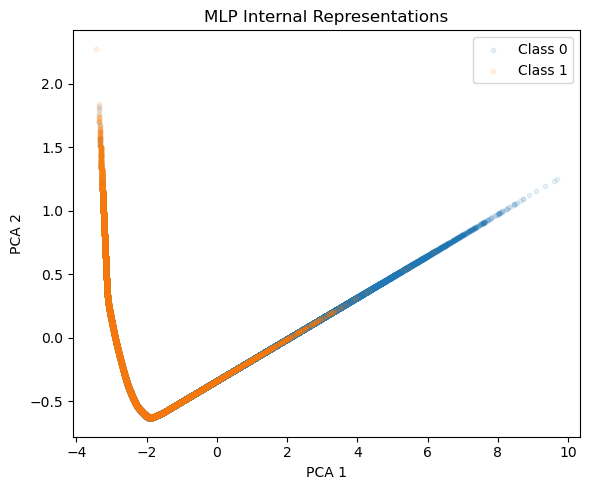

In [14]:
plot_embeddings(mlp_embedding, y_test, "MLP Internal Representations")